# **Business Understanding**

**About the data**
This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.



[data source](https://archive.ics.uci.edu/dataset/352/online+retail)

#### **Load Libraries**

In [116]:

import joblib # will help us package our final model
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#### **Load Data**

In [117]:
df = pd.read_excel("data/Online Retail.xlsx")

# **Data Understanding**

In [118]:
rows, columns = df.shape
output = f" Records: {rows} and features: {columns} " 
print(output)

 Records: 541909 and features: 8 


Checking for missing values

In [119]:
display(df.isna().sum()* 100 / len(df))

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

Checking for dupliates

In [120]:
# Get all rows where values appear more than once
all_duplicate_rows = df[df.duplicated(keep=False)]   
len(all_duplicate_rows)

10147

In [121]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [123]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"] 

In [124]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [125]:
all_duplicate_rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [126]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   TotalPrice   541909 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 37.2+ MB


#### **Univariate Analysis**

In [128]:
df["UnitPrice"].info()

<class 'pandas.Series'>
RangeIndex: 541909 entries, 0 to 541908
Series name: UnitPrice
Non-Null Count   Dtype  
--------------   -----  
541909 non-null  float64
dtypes: float64(1)
memory usage: 4.1 MB


In [129]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [130]:
df[["UnitPrice" , "TotalPrice"]].describe()

,UnitPrice,TotalPrice
count,541909.000000,541909.000000
mean,4.611114,17.987795
std,96.759853,378.810824
min,-11062.060000,-168469.600000
25%,1.250000,3.400000
50%,2.080000,9.750000
75%,4.130000,17.400000
max,38970.000000,168469.600000


In [131]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')

#### **Multivariate**

In [132]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,541909.000000,541909,541909.000000,406829.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,378.810824


In [133]:
df.describe(include = 'object')

/tmp/ipykernel_27187/1466716981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = 'object')


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


Current problems:
- Outliers are present
- Some values being large they tend to affect the general scale & MCTs
- Missing values & duplicate (this could be normal)

# **Data Preparation**

Cleaning the data

In [134]:
display(df.isna().sum()* 100 / len(df))

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
TotalPrice      0.000000
dtype: float64

Note:
- InvoiceNo: *Invoice* number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation. 

In [135]:
before_cleaning = len(df) # size of dataset before clearning
#  drpo missing values
df_2 = df.dropna(subset=["CustomerID"]) # dropped all missing values in cusotmer id

df_2 = df_2[~df_2["InvoiceNo"].astype(str).str.startswith("C")]
after_cleaning = len(df_2)
percentage_loss = ((before_cleaning - after_cleaning)/ before_cleaning)*100

summary = f" we have dropped {(percentage_loss):.2f}% of the data"
print(summary)


 we have dropped 26.57% of the data


In [136]:
display(df_2.isna().sum()* 100 / len(df_2))

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalPrice     0.0
dtype: float64

In [137]:
df_2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### Defining the Recency-Frequency-Monetary Analysis(RFM) based on customers, whereby the customer will represent one row

In [138]:
df_2.shape

(397924, 9)

In [139]:
df_2["CustomerID"].shape

(397924,)

In [140]:
df_2["CustomerID"].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4339,))

In [141]:
df_2["CustomerID"].nunique()

4339

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   TotalPrice   541909 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 37.2+ MB


In [143]:
df_2.info()

<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[us]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  str           
 8   TotalPrice   397924 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 30.4+ MB


In [144]:
df_2["CustomerID"]

0         17850.0
1         17850.0
2         17850.0
3         17850.0
4         17850.0
           ...   
541904    12680.0
541905    12680.0
541906    12680.0
541907    12680.0
541908    12680.0
Name: CustomerID, Length: 397924, dtype: float64

In [145]:
# filtering the transaction of customer with ID; 17850
df_client_one = df_2[df_2["CustomerID"] == 17850]
df_client_one

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
4540,536790,22752,SET 7 BABUSHKA NESTING BOXES,4,2010-12-02 15:26:00,7.65,17850.0,United Kingdom,30.60
4541,536790,22803,IVORY EMBROIDERED QUILT,3,2010-12-02 15:26:00,35.75,17850.0,United Kingdom,107.25
4542,536790,21730,GLASS STAR FROSTED T-LIGHT HOLDER,12,2010-12-02 15:26:00,4.25,17850.0,United Kingdom,51.00
4543,536791,22632,HAND WARMER RED POLKA DOT,12,2010-12-02 15:27:00,1.85,17850.0,United Kingdom,22.20


In [146]:
total_investment = (df_client_one["TotalPrice"].sum() ) * 171.23
total_investment

np.float64(923136.8883000001)

In [147]:
df_client_two = df_2[df_2["CustomerID"] == 12680]
total_investment = (df_client_two["TotalPrice"].sum() ) * 171.23
total_investment

np.float64(147738.95630000002)

In [148]:
df_client_three = df_2[df_2["CustomerID"] == 18287]
total_investment = (df_client_three["TotalPrice"].sum() ) * 171.23
total_investment

np.float64(314597.4544)

In [149]:
df_client_one["InvoiceNo"].describe()

count        297
unique        34
top       536750
freq          19
Name: InvoiceNo, dtype: int64

In [150]:
df_2["CustomerID"].describe() # note is id's are not necessaritly numerical fugures that can be summarized statisticall from a quantitative appraoch but can be analyzed based on a aqualitative approach

count    397924.000000
mean      15294.315171
std        1713.169877
min       12346.000000
25%       13969.000000
50%       15159.000000
75%       16795.000000
max       18287.000000
Name: CustomerID, dtype: float64

In [151]:
df_2["InvoiceNo"].describe()

count     397924
unique     18536
top       576339
freq         542
Name: InvoiceNo, dtype: int64

In [152]:
# 576339
highest_purchase = df_2[df_2["InvoiceNo"]==576339]
highest_purchase

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
466895,576339,10135,COLOURING PENCILS BROWN TUBE,14,2011-11-14 15:27:00,2.46,14096.0,United Kingdom,34.44
466896,576339,15044A,PINK PAPER PARASOL,1,2011-11-14 15:27:00,5.79,14096.0,United Kingdom,5.79
466897,576339,16238,PARTY TIME PENCIL ERASERS,2,2011-11-14 15:27:00,0.42,14096.0,United Kingdom,0.84
466898,576339,16258A,SWIRLY CIRCULAR RUBBERS IN BAG,1,2011-11-14 15:27:00,0.83,14096.0,United Kingdom,0.83
466899,576339,17003,BROCADE RING PURSE,2,2011-11-14 15:27:00,0.63,14096.0,United Kingdom,1.26
...,...,...,...,...,...,...,...,...,...
467432,576339,90083,CRYSTAL CZECH CROSS PHONE CHARM,1,2011-11-14 15:27:00,1.63,14096.0,United Kingdom,1.63
467433,576339,90086,CRYSTAL FROG PHONE CHARM,1,2011-11-14 15:27:00,1.63,14096.0,United Kingdom,1.63
467434,576339,90119,METALIC LEAVES BAG CHARMS,11,2011-11-14 15:27:00,2.46,14096.0,United Kingdom,27.06
467435,576339,90166,PINK & WHITE ROSEBUD RING,1,2011-11-14 15:27:00,4.15,14096.0,United Kingdom,4.15


In [153]:
highest_purchase["CustomerID"].unique()
total_investment = (highest_purchase["TotalPrice"].sum() ) 
total_investment

np.float64(8425.54)

In [154]:
top_client = df_2[df_2["CustomerID"]== 14096]
top_client

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
317502,564764,16207B,PINK HEART RED HANDBAG,1,2011-08-30 10:49:00,2.46,14096.0,United Kingdom,2.46
317503,564764,16225,RATTLE SNAKE EGGS,1,2011-08-30 10:49:00,3.29,14096.0,United Kingdom,3.29
317504,564764,16254,TRANSPARENT ACRYLIC TAPE DISPENSER,1,2011-08-30 10:49:00,1.63,14096.0,United Kingdom,1.63
317505,564764,84249A,"GREETING CARD,SQUARE, DOUGHNUTS",1,2011-08-30 10:49:00,0.83,14096.0,United Kingdom,0.83
317506,564764,84659A,WHITE TRAVEL ALARM CLOCK,2,2011-08-30 10:49:00,1.23,14096.0,United Kingdom,2.46
...,...,...,...,...,...,...,...,...,...
528082,580727,DOT,DOTCOM POSTAGE,1,2011-12-05 17:17:00,1599.26,14096.0,United Kingdom,1599.26
528083,580727,10135,COLOURING PENCILS BROWN TUBE,8,2011-12-05 17:17:00,2.46,14096.0,United Kingdom,19.68
528084,580727,11001,ASSTD DESIGN RACING CAR PEN,3,2011-12-05 17:17:00,3.29,14096.0,United Kingdom,9.87
528085,580727,15044A,PINK PAPER PARASOL,1,2011-12-05 17:17:00,5.79,14096.0,United Kingdom,5.79


In [155]:
df_client_one[df_client_one["InvoiceNo"]==536750]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
4161,536750,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12,2010-12-02 14:04:00,2.55,17850.0,United Kingdom,30.60
4162,536750,71053,WHITE METAL LANTERN,12,2010-12-02 14:04:00,3.39,17850.0,United Kingdom,40.68
4163,536750,84406B,CREAM CUPID HEARTS COAT HANGER,6,2010-12-02 14:04:00,2.75,17850.0,United Kingdom,16.50
4164,536750,15056BL,EDWARDIAN PARASOL BLACK,6,2010-12-02 14:04:00,4.95,17850.0,United Kingdom,29.70
4165,536750,20679,EDWARDIAN PARASOL RED,6,2010-12-02 14:04:00,4.95,17850.0,United Kingdom,29.70
4166,536750,37370,RETRO COFFEE MUGS ASSORTED,6,2010-12-02 14:04:00,1.06,17850.0,United Kingdom,6.36
4167,536750,21871,SAVE THE PLANET MUG,6,2010-12-02 14:04:00,1.06,17850.0,United Kingdom,6.36
4168,536750,21071,VINTAGE BILLBOARD DRINK ME MUG,6,2010-12-02 14:04:00,1.06,17850.0,United Kingdom,6.36
4169,536750,21068,VINTAGE BILLBOARD LOVE/HATE MUG,6,2010-12-02 14:04:00,1.06,17850.0,United Kingdom,6.36
4170,536750,82483,WOOD 2 DRAWER CABINET WHITE FINISH,4,2010-12-02 14:04:00,4.95,17850.0,United Kingdom,19.80


In [156]:
df["InvoiceDate"].describe()

count                        541909
mean     2011-07-04 13:34:57.156386
min             2010-12-01 08:26:00
25%             2011-03-28 11:34:00
50%             2011-07-19 17:17:00
75%             2011-10-19 11:27:00
max             2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

In [157]:
df_2["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [158]:
""""
NOTe:
- if a client makes a purchase on the last day of the transactions their receny may be calcuated as 0 to counter this we add one day to the last day using the pd.Timedelta(days = 1)
Helps calcluate the date since last purchase
"""
shop_financial_year_close_running = df_2["InvoiceDate"].max() + pd.Timedelta(days = 1) 
shop_financial_year_close_running

Timestamp('2011-12-10 12:50:00')

creating our Recency-Frequecy-Monetary dataframe createion

In [159]:
df_2.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [160]:
df_2["TotalPrice"] = df_2["Quantity"] * df_2["UnitPrice"]

In [161]:
df_2.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [162]:
df_2.shape

(397924, 9)

In [163]:
df_2[df_2["CustomerID"] == 17850].shape

(297, 9)

In [164]:
customer_17 = df_2[df_2["CustomerID"] == 17850]
customer_17.shape

(297, 9)

In [165]:
customer_17["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [166]:
customer_17["InvoiceDate"].max()

Timestamp('2010-12-02 15:27:00')

In [167]:
(customer_17["InvoiceDate"].max() - customer_17["InvoiceDate"].min()).days

1

In [168]:
customer_17["InvoiceDate"].unique()

<DatetimeArray>
['2010-12-01 08:26:00', '2010-12-01 08:28:00', '2010-12-01 09:01:00',
 '2010-12-01 09:02:00', '2010-12-01 09:32:00', '2010-12-01 09:34:00',
 '2010-12-01 10:51:00', '2010-12-01 10:52:00', '2010-12-01 11:33:00',
 '2010-12-01 11:34:00', '2010-12-02 08:32:00', '2010-12-02 08:33:00',
 '2010-12-02 08:34:00', '2010-12-02 08:40:00', '2010-12-02 09:41:00',
 '2010-12-02 09:42:00', '2010-12-02 09:44:00', '2010-12-02 10:54:00',
 '2010-12-02 10:55:00', '2010-12-02 10:56:00', '2010-12-02 10:58:00',
 '2010-12-02 12:23:00', '2010-12-02 12:24:00', '2010-12-02 12:25:00',
 '2010-12-02 12:26:00', '2010-12-02 14:04:00', '2010-12-02 14:05:00',
 '2010-12-02 14:06:00', '2010-12-02 14:07:00', '2010-12-02 15:24:00',
 '2010-12-02 15:25:00', '2010-12-02 15:26:00', '2010-12-02 15:27:00']
Length: 33, dtype: datetime64[us]

In [169]:
rfm_df = df_2.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda d: (shop_financial_year_close_running - d.max()).days ),
    Frequency= ("InvoiceNo", "nunique"),
    Monetary = ("TotalPrice", "sum")
)

In [170]:
df_2["CustomerID"].nunique()

4339

In [171]:
len(rfm_df) # this dataframe is composed of purely unique customer purcahase / RFM

4339

In [172]:
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [173]:
rows, columns = rfm_df.shape
output = f"we currently have {rows} customers their respective  RFM scores are in {columns} columns "
print(output)

we currently have 4339 customers their respective  RFM scores are in 3 columns 


In [174]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


In [175]:
customers = df_2["CustomerID"].unique() 
len(customers)

4339

In [176]:
def flagLarge(number):
    if number >= 280200:
        return f"====****{number}****===" 
    else:
        return number

In [177]:
for index,customer in enumerate(customers): 
    df_customer = df_2[df_2["CustomerID"] == customer]
    customer_investment = df_customer["TotalPrice"].sum()
    print(f"{index +1}. Customer ID: {customer} || investment {customer_investment}")
    if customer_investment >= 280200:
            break

1. Customer ID: 17850.0 || investment 5391.210000000001
2. Customer ID: 13047.0 || investment 3237.54
3. Customer ID: 12583.0 || investment 7281.379999999999
4. Customer ID: 13748.0 || investment 948.2499999999999
5. Customer ID: 15100.0 || investment 876.0
6. Customer ID: 15291.0 || investment 4668.300000000001
7. Customer ID: 14688.0 || investment 5630.870000000001
8. Customer ID: 17809.0 || investment 5411.91
9. Customer ID: 15311.0 || investment 60767.899999999994
10. Customer ID: 16098.0 || investment 2005.63
11. Customer ID: 18074.0 || investment 489.6
12. Customer ID: 17420.0 || investment 598.83
13. Customer ID: 16029.0 || investment 81024.84
14. Customer ID: 16250.0 || investment 389.44
15. Customer ID: 12431.0 || investment 6487.45
16. Customer ID: 17511.0 || investment 91062.38
17. Customer ID: 13705.0 || investment 711.86
18. Customer ID: 13747.0 || investment 79.6
19. Customer ID: 13408.0 || investment 28117.04
20. Customer ID: 13767.0 || investment 17220.36
21. Customer I

In [178]:
df_2[df_2["CustomerID"]==14646]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
37952,539491,21981,PACK OF 12 WOODLAND TISSUES,12,2010-12-20 10:09:00,0.29,14646.0,Netherlands,3.48
37953,539491,21986,PACK OF 12 PINK POLKADOT TISSUES,12,2010-12-20 10:09:00,0.29,14646.0,Netherlands,3.48
37954,539491,22720,SET OF 3 CAKE TINS PANTRY DESIGN,2,2010-12-20 10:09:00,4.95,14646.0,Netherlands,9.90
37955,539491,21931,JUMBO STORAGE BAG SUKI,1,2010-12-20 10:09:00,1.95,14646.0,Netherlands,1.95
37956,539491,22613,PACK OF 20 SPACEBOY NAPKINS,2,2010-12-20 10:09:00,0.85,14646.0,Netherlands,1.70
...,...,...,...,...,...,...,...,...,...
534958,581176,22908,PACK OF 20 NAPKINS RED APPLES,96,2011-12-07 15:19:00,0.72,14646.0,Netherlands,69.12
534959,581176,22907,PACK OF 20 NAPKINS PANTRY DESIGN,96,2011-12-07 15:19:00,0.72,14646.0,Netherlands,69.12
534960,581176,22029,SPACEBOY BIRTHDAY CARD,72,2011-12-07 15:19:00,0.36,14646.0,Netherlands,25.92
534961,581176,22712,CARD DOLLY GIRL,72,2011-12-07 15:19:00,0.36,14646.0,Netherlands,25.92


In [179]:
rfm_df.columns

Index(['Recency', 'Frequency', 'Monetary'], dtype='str')

In [180]:
rfm_df["Monetary"].describe()

count      4339.000000
mean       2053.793018
std        8988.248381
min           0.000000
25%         307.245000
50%         674.450000
75%        1661.640000
max      280206.020000
Name: Monetary, dtype: float64

In [181]:
# rfm_df.summary

In [182]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


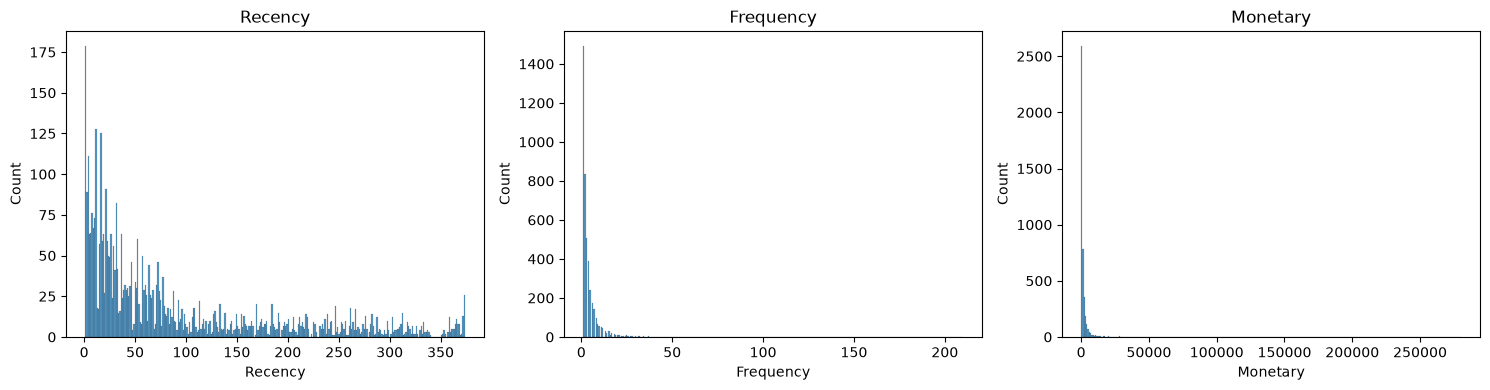

In [183]:
fig, axes = plt.subplots(1,3, figsize = (15,4))
for ax, col in zip(axes, rfm_df.columns):
    sns.histplot(rfm_df[col], bins=300 , ax= ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()

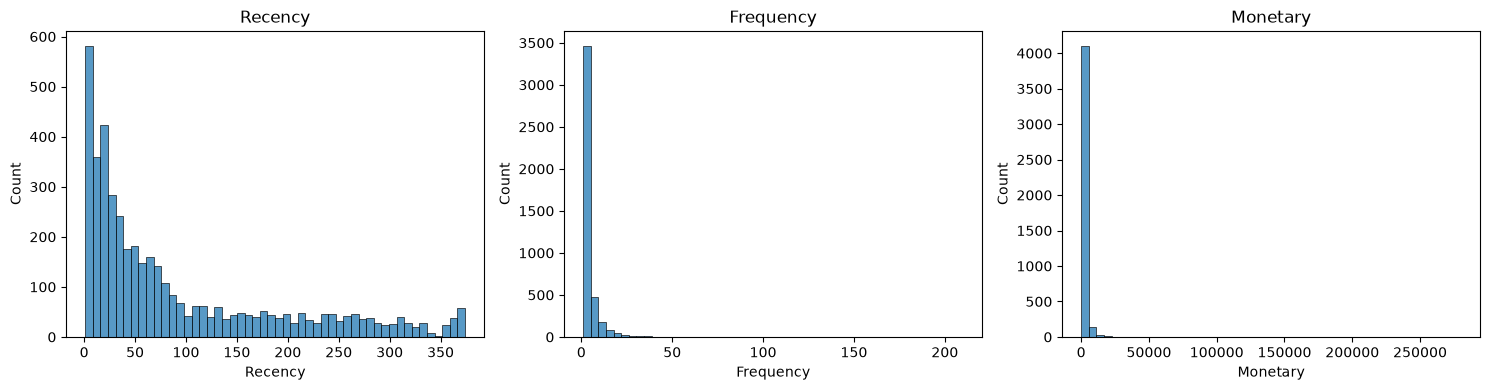

In [184]:
fig, axes = plt.subplots(1,3, figsize = (15,4))
for ax, col in zip(axes, rfm_df.columns):
    sns.histplot(rfm_df[col], bins=50 , ax= ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()

Preprocessing

In [185]:
#  implement log transform
rfm_log = np.log1p(rfm_df)


In [186]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


In [187]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,3.830475,1.345478,6.592108
std,1.340215,0.683138,1.261411
min,0.693147,0.693147,0.000000
25%,2.944439,0.693147,5.730895
50%,3.951244,1.098612,6.515379
75%,4.962845,1.791759,7.416162
max,5.926926,5.351858,12.543284


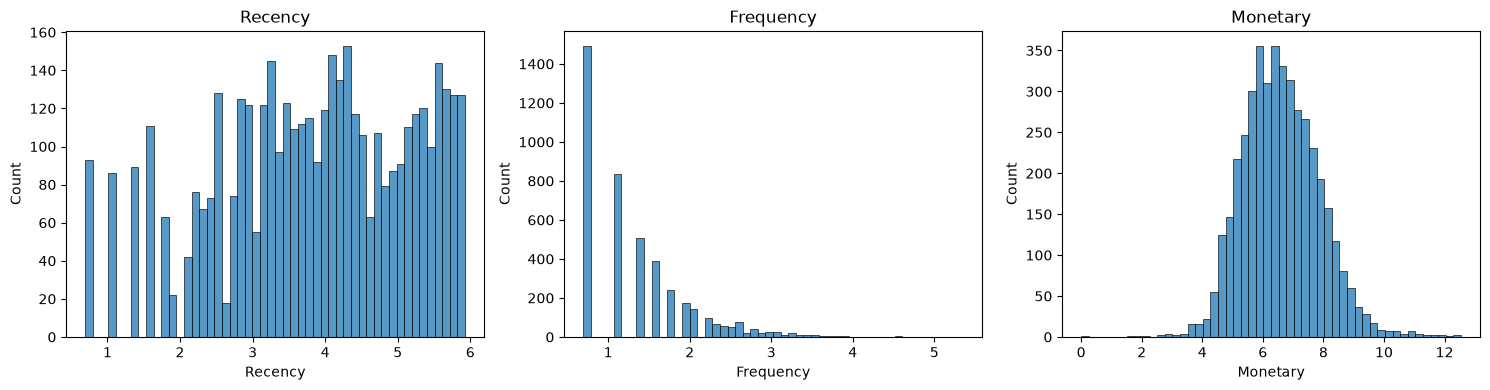

In [188]:

fig, axes = plt.subplots(1,3, figsize = (15,4))
for ax, col in zip(axes, rfm_log.columns):
    sns.histplot(rfm_log[col], bins=50 , ax= ax)
    ax.set_title(f"{col}")
plt.tight_layout()
plt.show()


In [189]:
# scaling
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
pd.DataFrame(X, columns = rfm_log.columns).describe().round(2)

,Recency,Frequency,Monetary
count,4339.00,4339.00,4339.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-5.23
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.06
75%,0.85,0.65,0.65
max,1.56,5.87,4.72


# **Data Modeling**

In [190]:
ks = range(2, 11)
inertias, sils = [],[]

for k in ks:
    km = KMeans(n_clusters=k, n_init = 10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

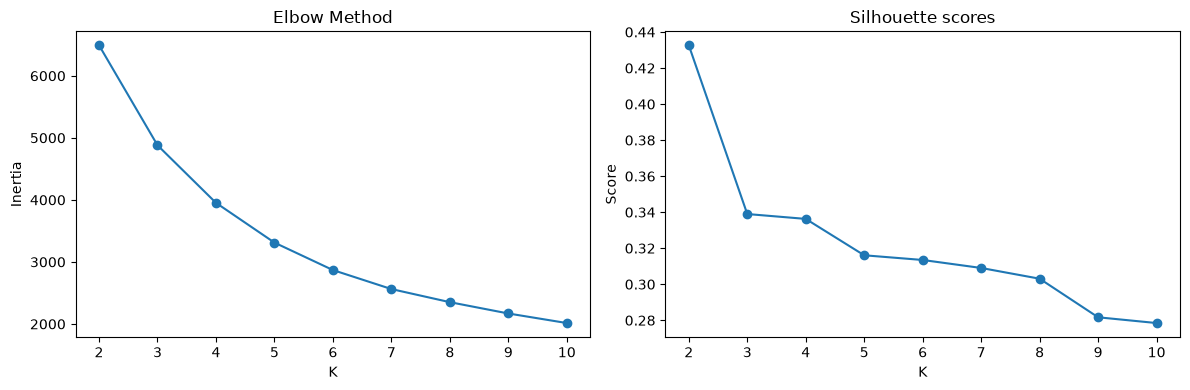

In [191]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
ax[0].plot(ks, inertias, "o-"); ax[0].set_title("Elbow Method"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sils, "o-"); ax[1].set_title("Silhouette scores"); ax[1].set_xlabel("K"); ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [192]:
pd.DataFrame({"k":list(ks), "inertia":inertias, "silohettes":sils}).round(3)

,k,inertia,silohettes
0,2,6492.916,0.433
1,3,4881.033,0.339
2,4,3952.593,0.336
3,5,3311.425,0.316
4,6,2868.907,0.313
5,7,2562.677,0.309
6,8,2351.334,0.303
7,9,2168.931,0.282
8,10,2014.787,0.278


In [193]:
# Cluster 
k = 4 
km = KMeans(n_clusters=k, n_init = 10, random_state=42)
rfm_log["Cluster"] = km.fit_predict(X)
rfm_log["Cluster"].value_counts().sort_index()


Cluster
0     839
1     723
2    1183
3    1594
Name: count, dtype: int64

In [194]:
rfm_log.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,5.789960,0.693147,11.253955,2
12347.0,1.098612,2.079442,8.368925,1
12348.0,4.330733,1.609438,7.494564,2
12349.0,2.995732,0.693147,7.472245,0
12350.0,5.739793,0.693147,5.815324,3


In [195]:

k = 4 
km = KMeans(n_clusters=k, n_init = 10, random_state=42)
rfm_df["Cluster"] = km.fit_predict(X)
rfm_df["Cluster"].value_counts().sort_index()

Cluster
0     839
1     723
2    1183
3    1594
Name: count, dtype: int64

In [196]:
rfm_df.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,3


In [197]:
profile = rfm_df.groupby("Cluster").agg(
    Recency =("Recency","mean"),
    Frequency = ("Frequency", "mean"),
    Monetary =("Monetary", "mean"),
    Customers =("Recency", "size")    
)
profile["% Share"] = profile["Customers"] / len(rfm_df) * 100
profile.sort_values("Monetary", ascending = False)

,Recency,Frequency,Monetary,Customers,% Share
Cluster,,,,,
1,12.112033,13.634855,8015.424412,723,16.662826
2,70.697380,4.076923,1791.090873,1183,27.264347
0,18.725864,2.090584,538.231287,839,19.336253
3,184.023839,1.318068,342.421268,1594,36.736575


In [198]:
cluster_group_names= {
    1:"Champion",
    2:"At Risk",
    0:"NEW Customer", 
    3:"LOST Customer"
}

rfm_df["Status"] = rfm_df["Cluster"].map(cluster_group_names)
rfm_df

,Recency,Frequency,Monetary,Cluster,Status
CustomerID,,,,,
12346.0,326,1,77183.60,2,At Risk
12347.0,2,7,4310.00,1,Champion
12348.0,75,4,1797.24,2,At Risk
12349.0,19,1,1757.55,0,NEW Customer
12350.0,310,1,334.40,3,LOST Customer
...,...,...,...,...,...
18280.0,278,1,180.60,3,LOST Customer
18281.0,181,1,80.82,3,LOST Customer
18282.0,8,2,178.05,0,NEW Customer


In [199]:
champions_df = rfm_df[rfm_df["Status"] =="Champion"]
champions_df

,Recency,Frequency,Monetary,Cluster,Status
CustomerID,,,,,
12347.0,2,7,4310.00,1,Champion
12362.0,3,10,5226.23,1,Champion
12381.0,5,5,1845.31,1,Champion
12388.0,16,6,2780.66,1,Champion
12395.0,19,12,3018.63,1,Champion
...,...,...,...,...,...
18230.0,9,7,2810.20,1,Champion
18241.0,10,17,2073.09,1,Champion
18245.0,7,7,2567.06,1,Champion


In [200]:
champions_df["Monetary"].sum()

np.float64(5795151.85)

Fit the KMeans with the optimal number of cluster s
add the customer segmenets to the df =.> rfm_log
add a columns indicating the nube rof customers per cluster in %
save model using joblib

In [210]:
# testing model with actual inputs
more_customers = pd.DataFrame(
    {
        "Recency": [3,183,15,308],
        "Frequency":[40,25,1,1],
        "Monetary":[8000, 4500,1200, 30] 
    },
    index =["Amina", "Brian", "Cynthia", "David"]
)
more_customers

,Recency,Frequency,Monetary
Amina,3,40,8000
Brian,183,25,4500
Cynthia,15,1,1200
David,308,1,30


In [211]:
more_customers.describe()

,Recency,Frequency,Monetary
count,4.000000,4.000000,4.000000
mean,127.250000,16.750000,3432.500000
std,145.850094,19.189841,3585.278929
min,3.000000,1.000000,30.000000
25%,12.000000,1.000000,907.500000
50%,99.000000,13.000000,2850.000000
75%,214.250000,28.750000,5375.000000
max,308.000000,40.000000,8000.000000


In [212]:
more_customers_log_transform = np.log1p(more_customers) 

In [213]:
more_customers_log_transform.head()

,Recency,Frequency,Monetary
Amina,1.386294,3.713572,8.987322
Brian,5.214936,3.258097,8.412055
Cynthia,2.772589,0.693147,7.090910
David,5.733341,0.693147,3.433987


In [214]:
more_customers_log_transform.describe()

,Recency,Frequency,Monetary
count,4.000000,4.000000,4.000000
mean,3.776790,2.089491,6.981068
std,2.050955,1.623046,2.494435
min,1.386294,0.693147,3.433987
25%,2.426015,0.693147,6.176679
50%,3.993762,1.975622,7.751482
75%,5.344537,3.371965,8.555872
max,5.733341,3.713572,8.987322


In [215]:
x_new = scaler.transform(more_customers_log_transform)
x_new

array([[-1.82393302,  3.4668914 ,  1.89905677],
       [ 1.03313286,  2.80007485,  1.4429537 ],
       [-0.78943177, -0.95501313,  0.39547772],
       [ 1.41998516, -0.95501313, -2.50393035]])

In [216]:
more_customers["Cluster"] = km.predict(x_new)
more_customers["Status"] = more_customers["Cluster"].map(cluster_group_names)
more_customers


,Recency,Frequency,Monetary,Cluster,Status
Amina,3,40,8000,1,Champion
Brian,183,25,4500,1,Champion
Cynthia,15,1,1200,0,NEW Customer
David,308,1,30,3,LOST Customer


# **Evaluation**

# **Deployment**

In [218]:
joblib.dump(
    {
        "scaler":scaler,
        "kmeans":km,
        "cluster_names":cluster_group_names    
    },
    "rfm_kmeans.joblib"
)

['rfm_kmeans.joblib']